In [ ]:
!git clone https://github.com/lululxvi/deepxde.git


Cloning into 'deepxde'...
remote: Enumerating objects: 8788, done.
remote: Counting objects: 100% (1099/1099), done.
remote: Compressing objects: 100% (327/327), done.
remote: Total 8788 (delta 963), reused 772 (delta 772), pack-reused 7689 (from 3)
Receiving objects: 100% (8788/8788), 28.03 MiB | 27.08 MiB/s, done.
Resolving deltas: 100% (6296/6296), done.


In [ ]:
%cd deepxde

/content/deepxde


In [ ]:
!pip install deepxde torch numpy scipy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 10.2 MB/s eta 0:00:00


In [ ]:
%cd examples

/content/deepxde/examples


In [ ]:
!pwd
!ls

/content/deepxde/examples
dataset   Makefile  pinn_forward  sample_to_test.py
function  operator  pinn_inverse


In [ ]:
%cd /content/deepxde/examples/pinn_forward
!ls

/content/deepxde/examples/pinn_forward
Allen_Cahn.py		       Helmholtz_Sound_hard_ABC_2d.py
Beltrami_flow.py	       ide.py
Burgers.py		       Klein_Gordon.py
Burgers_RAR.py		       Kovasznay_flow.py
diffusion_1d_exactBC.py        Laplace_disk.py
diffusion_1d.py		       Lotka_Volterra.py
diffusion_1d_resample.py       ode_2nd.py
diffusion_reaction.py	       ode_system.py
elasticity_plate.py	       Poisson_Dirichlet_1d_exactBC.py
Euler_beam.py		       Poisson_Dirichlet_1d.py
fractional_diffusion_1d.py     Poisson_Lshape.py
fractional_Poisson_1d.py       Poisson_multiscale_1d.py
fractional_Poisson_2d.py       Poisson_Neumann_1d.py
fractional_Poisson_3d.py       Poisson_periodic_1d.py
heat.py			       Poisson_PointSetOperator_1d.py
heat_resample.py	       Poisson_Robin_1d.py
Helmholtz_Dirichlet_2d_HPO.py  Schrodinger.ipynb
Helmholtz_Dirichlet_2d.py      Volterra_IDE.py
Helmholtz_Neumann_2d_hole.py   wave_1d.py


In [ ]:
!python diffusion_reaction.py

No backend selected.
Finding available backend...
2026-05-02 11:18:18.538168: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-02 11:18:18.602849: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Found tensorflow
Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.
2026-05-02 11:18:26.582562: E external/local_xla/xla/stream_executor/cuda/cuda_platform

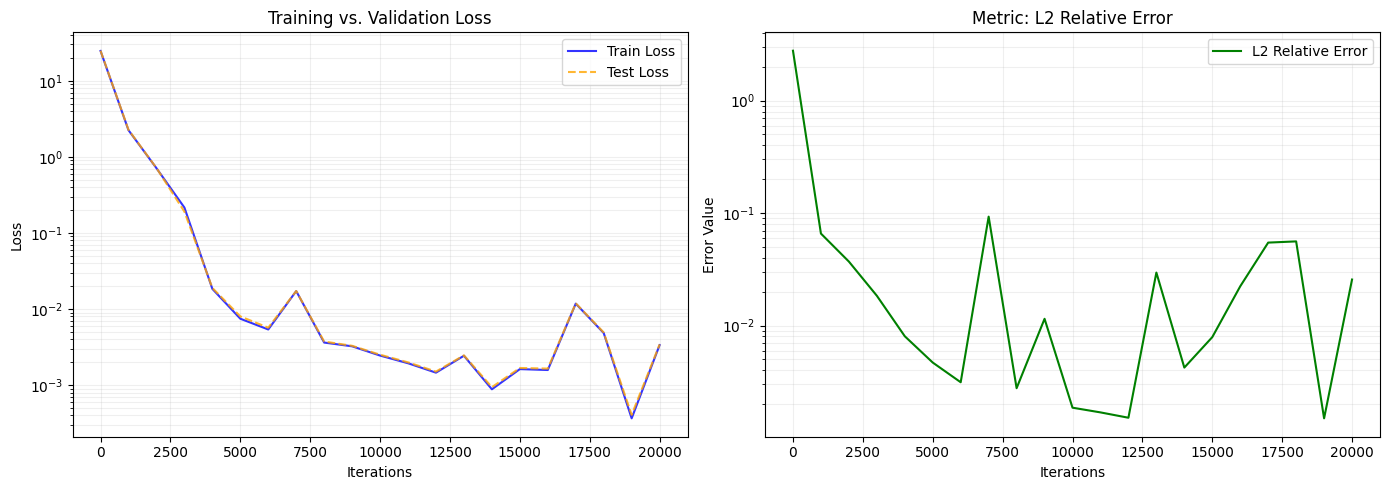

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data generated by your script
# Column 0: Steps
# Column 1: Training Loss
# Column 2: Test/Validation Loss
# Column 3: L2 Relative Error (Metric)
try:
    data = np.loadtxt("loss.dat")
except OSError:
    print("Error: 'loss.dat' not found. Please ensure your script has finished running.")
    exit()

steps = data[:, 0]
train_loss = data[:, 1]
test_loss = data[:, 2]
l2_error = data[:, 3]

# Create a figure with two subplots: Loss and Metric
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training and Validation Loss
ax1.plot(steps, train_loss, label="Train Loss", color='blue', alpha=0.8)
ax1.plot(steps, test_loss, label="Test Loss", color='orange', linestyle='--', alpha=0.8)
ax1.set_yscale("log")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs. Validation Loss")
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Plot 2: L2 Relative Error
ax2.plot(steps, l2_error, label="L2 Relative Error", color='green')
ax2.set_yscale("log")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Error Value")
ax2.set_title("Metric: L2 Relative Error")
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Compiling model...
'compile' took 0.028626 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.13e+01]    [1.15e+01]    [6.32e-01]    
1000      [1.46e-01]    [1.50e-01]    [7.74e-02]    
2000      [3.33e-02]    [3.41e-02]    [4.05e-02]    
3000      [1.85e-02]    [1.89e-02]    [2.32e-02]    
4000      [1.44e-02]    [1.48e-02]    [1.16e-02]    
5000      [5.27e-03]    [5.67e-03]    [1.21e-02]    
6000      [1.51e-02]    [1.56e-02]    [4.41e-02]    
7000      [9.96e-03]    [1.03e-02]    [4.89e-02]    
8000      [1.43e-02]    [1.46e-02]    [5.23e-02]    
9000      [6.46e-03]    [6.73e-03]    [3.05e-02]    
10000     [1.43e-02]    [1.44e-02]    [1.35e-02]    
11000     [3.92e-03]    [4.07e-03]    [1.93e-02]    
12000     [7.00e-03]    [7.18e-03]    [8.05e-03]    
13000     [4.06e-03]    [4.08e-03]    [5.95e-03]    
14000     [1.06e-02]    [1.08e-02]    [2.04e-02]    
15000     [2.62e-03]    [2.64e-03]    [1.30e-02]    
16000     [1.54e-03]    [1.57e-03]

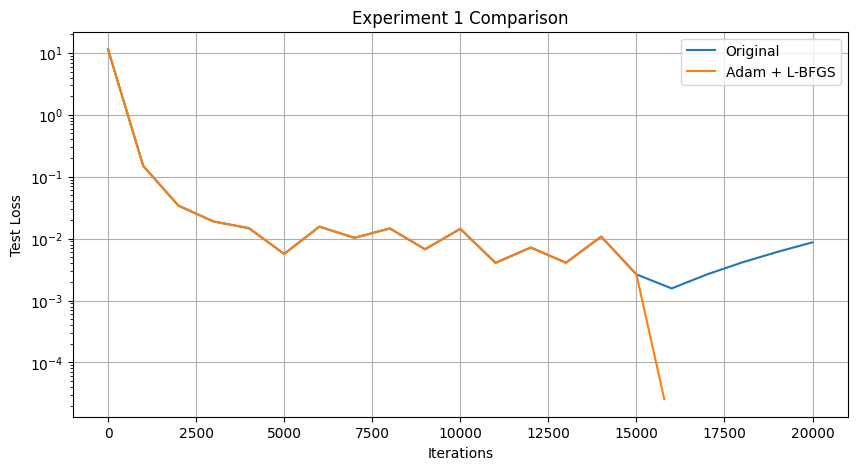

In [ ]:
# ===============================================================
# EXPERIMENT 1 (CLEAN)
# ORIGINAL vs IMPROVED (Adam + L-BFGS)
# ===============================================================

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from deepxde.backend import tf

# ---------------- PDE ----------------
def pde(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t - dy_xx - tf.exp(-x[:,1:]) * (
        3*tf.sin(2*x[:,0:1])/2 +
        8*tf.sin(3*x[:,0:1])/3 +
        15*tf.sin(4*x[:,0:1])/4 +
        63*tf.sin(8*x[:,0:1])/8
    )

def func(x):
    return np.exp(-x[:,1:]) * (
        np.sin(x[:,0:1]) +
        np.sin(2*x[:,0:1])/2 +
        np.sin(3*x[:,0:1])/3 +
        np.sin(4*x[:,0:1])/4 +
        np.sin(8*x[:,0:1])/8
    )

geom = dde.geometry.Interval(-np.pi,np.pi)
timedomain = dde.geometry.TimeDomain(0,1)
geomtime = dde.geometry.GeometryXTime(geom,timedomain)

data = dde.data.TimePDE(geomtime,pde,[],num_domain=320,solution=func,num_test=80000)

def output_transform(x,y):
    return x[:,1:2]*(np.pi**2-x[:,0:1]**2)*y + \
           tf.sin(x[:,0:1]) + tf.sin(2*x[:,0:1])/2 + \
           tf.sin(3*x[:,0:1])/3 + tf.sin(4*x[:,0:1])/4 + \
           tf.sin(8*x[:,0:1])/8

# -------- Original --------
net1 = dde.nn.FNN([2]+[30]*6+[1], "tanh", "Glorot uniform")
net1.apply_output_transform(output_transform)

model1 = dde.Model(data, net1)
model1.compile("adam", lr=1e-3, metrics=["l2 relative error"])
lh1, ts1 = model1.train(iterations=20000)

# -------- Improved --------
net2 = dde.nn.FNN([2]+[30]*6+[1], "tanh", "Glorot uniform")
net2.apply_output_transform(output_transform)

model2 = dde.Model(data, net2)
model2.compile("adam", lr=1e-3, metrics=["l2 relative error"])
model2.train(iterations=15000)

model2.compile("L-BFGS", metrics=["l2 relative error"])
lh2, ts2 = model2.train()

# -------- Metrics --------
orig_err = np.min(np.array(ts1.metrics_test))
imp_err  = np.min(np.array(ts2.metrics_test))

print("\n===== RESULTS =====")
print(f"Original Best L2 Error : {orig_err:.6e}")
print(f"Improved Best L2 Error: {imp_err:.6e}")
print(f"Improvement Factor    : {orig_err/imp_err:.2f}x better")

# -------- Plot --------
plt.figure(figsize=(10,5))
plt.semilogy(lh1.steps,[x[0] for x in lh1.loss_test],label="Original")
plt.semilogy(lh2.steps,[x[0] for x in lh2.loss_test],label="Adam + L-BFGS")
plt.xlabel("Iterations")
plt.ylabel("Test Loss")
plt.title("Experiment 1 Comparison")
plt.legend()
plt.grid(True)
plt.show()

Compiling model...
'compile' took 0.006746 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.13e+01]    [1.15e+01]    [6.32e-01]    
1000      [1.46e-01]    [1.50e-01]    [7.74e-02]    
2000      [3.33e-02]    [3.41e-02]    [4.05e-02]    
3000      [1.85e-02]    [1.89e-02]    [2.32e-02]    
4000      [1.44e-02]    [1.48e-02]    [1.16e-02]    
5000      [5.27e-03]    [5.67e-03]    [1.21e-02]    
6000      [1.51e-02]    [1.56e-02]    [4.41e-02]    
7000      [9.96e-03]    [1.03e-02]    [4.89e-02]    
8000      [1.43e-02]    [1.46e-02]    [5.23e-02]    
9000      [6.46e-03]    [6.73e-03]    [3.05e-02]    
10000     [1.43e-02]    [1.44e-02]    [1.35e-02]    
11000     [3.92e-03]    [4.07e-03]    [1.93e-02]    
12000     [7.00e-03]    [7.18e-03]    [8.05e-03]    
13000     [4.06e-03]    [4.08e-03]    [5.95e-03]    
14000     [1.06e-02]    [1.08e-02]    [2.04e-02]    
15000     [2.62e-03]    [2.64e-03]    [1.30e-02]    
16000     [1.54e-03]    [1.57e-03]

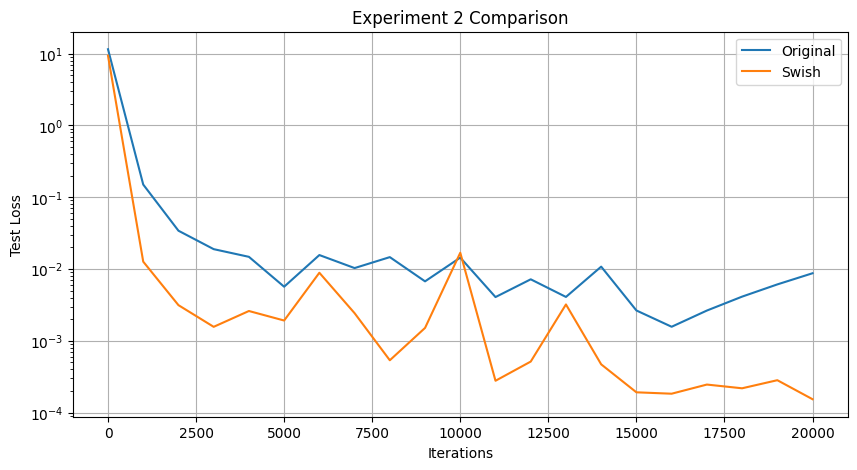

In [ ]:
# ===============================================================
# EXPERIMENT 2
# ORIGINAL vs SWISH ACTIVATION
# ===============================================================

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from deepxde.backend import tf

# Uses same pde, func, data, output_transform from above

net1 = dde.nn.FNN([2]+[30]*6+[1], "tanh", "Glorot uniform")
net1.apply_output_transform(output_transform)

model1 = dde.Model(data, net1)
model1.compile("adam", lr=1e-3, metrics=["l2 relative error"])
lh1, ts1 = model1.train(iterations=20000)

net2 = dde.nn.FNN([2]+[30]*6+[1], "swish", "Glorot uniform")
net2.apply_output_transform(output_transform)

model2 = dde.Model(data, net2)
model2.compile("adam", lr=1e-3, metrics=["l2 relative error"])
lh2, ts2 = model2.train(iterations=20000)

orig_err = np.min(np.array(ts1.metrics_test))
imp_err  = np.min(np.array(ts2.metrics_test))

print("\n===== RESULTS =====")
print(f"Original Best L2 Error : {orig_err:.6e}")
print(f"Swish Best L2 Error    : {imp_err:.6e}")
print(f"Improvement Factor     : {orig_err/imp_err:.2f}x better")

plt.figure(figsize=(10,5))
plt.semilogy(lh1.steps,[x[0] for x in lh1.loss_test],label="Original")
plt.semilogy(lh2.steps,[x[0] for x in lh2.loss_test],label="Swish")
plt.xlabel("Iterations")
plt.ylabel("Test Loss")
plt.title("Experiment 2 Comparison")
plt.legend()
plt.grid(True)
plt.show()

Compiling model...
'compile' took 0.004628 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.13e+01]    [1.15e+01]    [6.32e-01]    
1000      [1.46e-01]    [1.50e-01]    [7.74e-02]    
2000      [3.33e-02]    [3.41e-02]    [4.05e-02]    
3000      [1.85e-02]    [1.89e-02]    [2.32e-02]    
4000      [1.44e-02]    [1.48e-02]    [1.16e-02]    
5000      [5.27e-03]    [5.67e-03]    [1.21e-02]    
6000      [1.51e-02]    [1.56e-02]    [4.41e-02]    
7000      [9.96e-03]    [1.03e-02]    [4.89e-02]    
8000      [1.43e-02]    [1.46e-02]    [5.23e-02]    
9000      [6.46e-03]    [6.73e-03]    [3.05e-02]    
10000     [1.43e-02]    [1.44e-02]    [1.35e-02]    
11000     [3.92e-03]    [4.07e-03]    [1.93e-02]    
12000     [7.00e-03]    [7.18e-03]    [8.05e-03]    
13000     [4.06e-03]    [4.08e-03]    [5.95e-03]    
14000     [1.06e-02]    [1.08e-02]    [2.04e-02]    
15000     [2.62e-03]    [2.64e-03]    [1.30e-02]    
16000     [1.54e-03]    [1.57e-03]

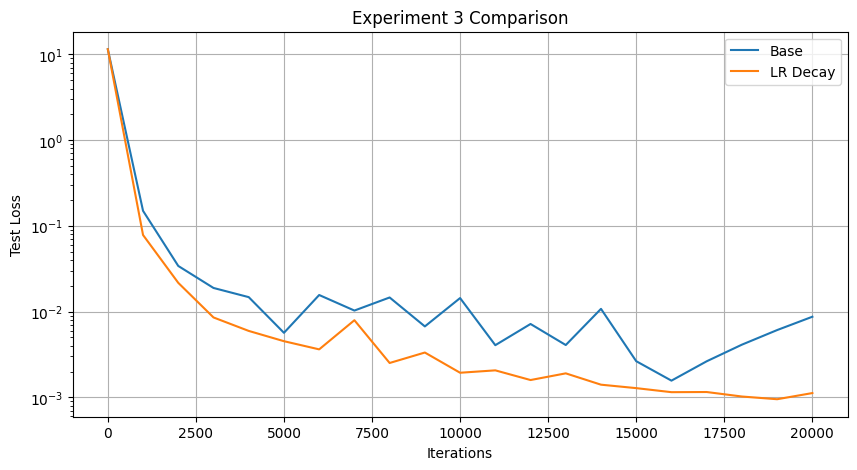

In [ ]:
# ===============================================================
# EXPERIMENT 3
# BASE MODEL vs LEARNING RATE DECAY
# ===============================================================

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from deepxde.backend import tf

# ---------------- PDE ----------------
def pde(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t - dy_xx - tf.exp(-x[:,1:]) * (
        3*tf.sin(2*x[:,0:1])/2 +
        8*tf.sin(3*x[:,0:1])/3 +
        15*tf.sin(4*x[:,0:1])/4 +
        63*tf.sin(8*x[:,0:1])/8
    )

def func(x):
    return np.exp(-x[:,1:]) * (
        np.sin(x[:,0:1]) +
        np.sin(2*x[:,0:1])/2 +
        np.sin(3*x[:,0:1])/3 +
        np.sin(4*x[:,0:1])/4 +
        np.sin(8*x[:,0:1])/8
    )

geom = dde.geometry.Interval(-np.pi, np.pi)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

data = dde.data.TimePDE(
    geomtime, pde, [], num_domain=320,
    solution=func, num_test=80000
)

def output_transform(x, y):
    return x[:,1:2]*(np.pi**2 - x[:,0:1]**2)*y + \
           tf.sin(x[:,0:1]) + tf.sin(2*x[:,0:1])/2 + \
           tf.sin(3*x[:,0:1])/3 + tf.sin(4*x[:,0:1])/4 + \
           tf.sin(8*x[:,0:1])/8

# ---------------- BASE ----------------
net1 = dde.nn.FNN([2]+[30]*6+[1], "tanh", "Glorot uniform")
net1.apply_output_transform(output_transform)

model1 = dde.Model(data, net1)
model1.compile("adam", lr=1e-3, metrics=["l2 relative error"])
lh1, ts1 = model1.train(iterations=20000)

# ---------------- IMPROVED ----------------
net2 = dde.nn.FNN([2]+[30]*6+[1], "tanh", "Glorot uniform")
net2.apply_output_transform(output_transform)

model2 = dde.Model(data, net2)
model2.compile(
    "adam",
    lr=1e-3,
    decay=("inverse time", 2000, 0.5),
    metrics=["l2 relative error"]
)
lh2, ts2 = model2.train(iterations=20000)

# ---------------- RESULTS ----------------
base_err = np.min(np.array(ts1.metrics_test))
new_err  = np.min(np.array(ts2.metrics_test))

print("\n===== CELL 5 RESULTS =====")
print("Base L2 Error       :", base_err)
print("LR Decay L2 Error   :", new_err)
print("Improvement Factor  :", base_err/new_err)

plt.figure(figsize=(10,5))
plt.semilogy(lh1.steps,[x[0] for x in lh1.loss_test],label="Base")
plt.semilogy(lh2.steps,[x[0] for x in lh2.loss_test],label="LR Decay")
plt.xlabel("Iterations")
plt.ylabel("Test Loss")
plt.title("Experiment 3 Comparison")
plt.legend()
plt.grid(True)
plt.show()

Compiling model...
'compile' took 0.004372 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.13e+01]    [1.15e+01]    [6.32e-01]    
1000      [1.46e-01]    [1.50e-01]    [7.74e-02]    
2000      [3.33e-02]    [3.41e-02]    [4.05e-02]    
3000      [1.85e-02]    [1.89e-02]    [2.32e-02]    
4000      [1.44e-02]    [1.48e-02]    [1.16e-02]    
5000      [5.27e-03]    [5.67e-03]    [1.21e-02]    
6000      [1.51e-02]    [1.56e-02]    [4.41e-02]    
7000      [9.96e-03]    [1.03e-02]    [4.89e-02]    
8000      [1.43e-02]    [1.46e-02]    [5.23e-02]    
9000      [6.46e-03]    [6.73e-03]    [3.05e-02]    
10000     [1.43e-02]    [1.44e-02]    [1.35e-02]    
11000     [3.92e-03]    [4.07e-03]    [1.93e-02]    
12000     [7.00e-03]    [7.18e-03]    [8.05e-03]    
13000     [4.06e-03]    [4.08e-03]    [5.95e-03]    
14000     [1.06e-02]    [1.08e-02]    [2.04e-02]    
15000     [2.62e-03]    [2.64e-03]    [1.30e-02]    
16000     [1.54e-03]    [1.57e-03]

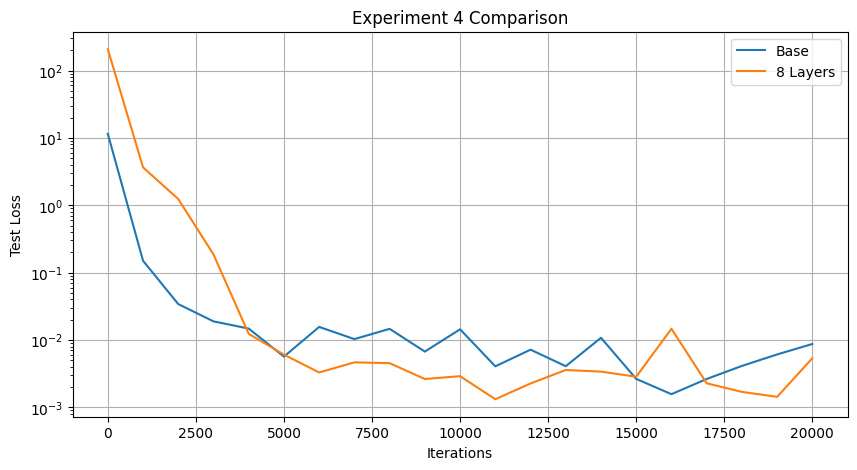

In [ ]:
# ===============================================================
# EXPERIMENT 4
# BASE MODEL vs DEEPER NETWORK
# ===============================================================

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from deepxde.backend import tf

# assumes same pde, func, data, output_transform already defined

# ---------------- BASE ----------------
net1 = dde.nn.FNN([2]+[30]*6+[1], "tanh", "Glorot uniform")
net1.apply_output_transform(output_transform)

model1 = dde.Model(data, net1)
model1.compile("adam", lr=1e-3, metrics=["l2 relative error"])
lh1, ts1 = model1.train(iterations=20000)

# ---------------- IMPROVED ----------------
net2 = dde.nn.FNN([2]+[30]*8+[1], "tanh", "Glorot uniform")
net2.apply_output_transform(output_transform)

model2 = dde.Model(data, net2)
model2.compile("adam", lr=1e-3, metrics=["l2 relative error"])
lh2, ts2 = model2.train(iterations=20000)

# ---------------- RESULTS ----------------
base_err = np.min(np.array(ts1.metrics_test))
new_err  = np.min(np.array(ts2.metrics_test))

print("\n===== CELL 6 RESULTS =====")
print("Base L2 Error       :", base_err)
print("Deeper Net L2 Error :", new_err)
print("Improvement Factor  :", base_err/new_err)

plt.figure(figsize=(10,5))
plt.semilogy(lh1.steps,[x[0] for x in lh1.loss_test],label="Base")
plt.semilogy(lh2.steps,[x[0] for x in lh2.loss_test],label="8 Layers")
plt.xlabel("Iterations")
plt.ylabel("Test Loss")
plt.title("Experiment 4 Comparison")
plt.legend()
plt.grid(True)
plt.show()

Compiling model...
'compile' took 0.005314 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.13e+01]    [1.15e+01]    [6.32e-01]    
1000      [1.46e-01]    [1.50e-01]    [7.74e-02]    
2000      [3.33e-02]    [3.41e-02]    [4.05e-02]    
3000      [1.85e-02]    [1.89e-02]    [2.32e-02]    
4000      [1.44e-02]    [1.48e-02]    [1.16e-02]    
5000      [5.27e-03]    [5.67e-03]    [1.21e-02]    
6000      [1.51e-02]    [1.56e-02]    [4.41e-02]    
7000      [9.96e-03]    [1.03e-02]    [4.89e-02]    
8000      [1.43e-02]    [1.46e-02]    [5.23e-02]    
9000      [6.46e-03]    [6.73e-03]    [3.05e-02]    
10000     [1.43e-02]    [1.44e-02]    [1.35e-02]    
11000     [3.92e-03]    [4.07e-03]    [1.93e-02]    
12000     [7.00e-03]    [7.18e-03]    [8.05e-03]    
13000     [4.06e-03]    [4.08e-03]    [5.95e-03]    
14000     [1.06e-02]    [1.08e-02]    [2.04e-02]    
15000     [2.62e-03]    [2.64e-03]    [1.30e-02]    
16000     [1.54e-03]    [1.57e-03]

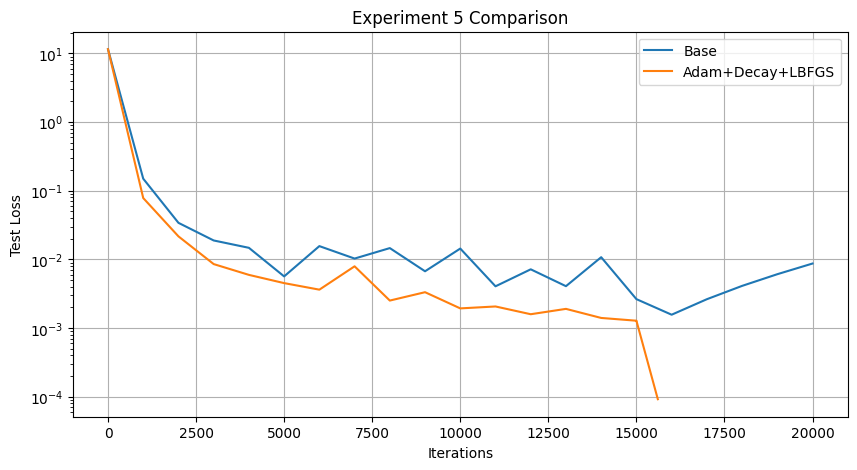

In [ ]:
# ===============================================================
# EXPERIMENT 5
# BASE MODEL vs ADAM + LR DECAY + L-BFGS (BEST FINAL TRY)
# ===============================================================

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from deepxde.backend import tf

# assumes same pde, func, data, output_transform already defined

# ---------------- BASE ----------------
net1 = dde.nn.FNN([2]+[30]*6+[1], "tanh", "Glorot uniform")
net1.apply_output_transform(output_transform)

model1 = dde.Model(data, net1)
model1.compile("adam", lr=1e-3, metrics=["l2 relative error"])
lh1, ts1 = model1.train(iterations=20000)

# ---------------- IMPROVED ----------------
net2 = dde.nn.FNN([2]+[30]*6+[1], "tanh", "Glorot uniform")
net2.apply_output_transform(output_transform)

model2 = dde.Model(data, net2)

model2.compile(
    "adam",
    lr=1e-3,
    decay=("inverse time", 2000, 0.5),
    metrics=["l2 relative error"]
)
model2.train(iterations=15000)

model2.compile("L-BFGS", metrics=["l2 relative error"])
lh2, ts2 = model2.train()

# ---------------- RESULTS ----------------
base_err = np.min(np.array(ts1.metrics_test))
new_err  = np.min(np.array(ts2.metrics_test))

print("\n===== CELL 7 RESULTS =====")
print("Base L2 Error           :", base_err)
print("Hybrid Final L2 Error   :", new_err)
print("Improvement Factor      :", base_err/new_err)

plt.figure(figsize=(10,5))
plt.semilogy(lh1.steps,[x[0] for x in lh1.loss_test],label="Base")
plt.semilogy(lh2.steps,[x[0] for x in lh2.loss_test],label="Adam+Decay+LBFGS")
plt.xlabel("Iterations")
plt.ylabel("Test Loss")
plt.title("Experiment 5 Comparison")
plt.legend()
plt.grid(True)
plt.show()